In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [7]:
# Let's rename all the files first:

rateList = np.logspace(-4,3,8)
probList = np.linspace(0,0.3,7).round(2)


In [8]:
print(probList)

[0.   0.05 0.1  0.15 0.2  0.25 0.3 ]


In [10]:
NList = [4,6,8,10]

avgedMI_dynamics_0 = {}
avgedMI_steady_0 = {}

rate=0

avgedMI_dynamics_0[rate] = {}
avgedMI_steady_0[rate] = {}

for prob in probList: 
    avgedMI_steady_0[rate][prob] = np.zeros(4)

    for (n,N) in enumerate(NList): 

        if os.path.isfile("RC_mixed_initial_state/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
            temp = np.array(np.loadtxt("RC_mixed_initial_state/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
            #print(np.average(temp,axis=0).shape)
            avgedMI_dynamics_0[rate][prob] = np.average(temp,axis=0)

            steps = len(temp)//2

            avgedMI_steady_0[rate][prob][n] = np.average(temp[steps:])

        else:
            #print("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out")
            print('missing rate=',rate,',prob=', prob,'N=',N)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



(30, 80)
(30, 80)
(30, 80)
(30, 80)
(30, 80)
(30, 80)
(30, 80)


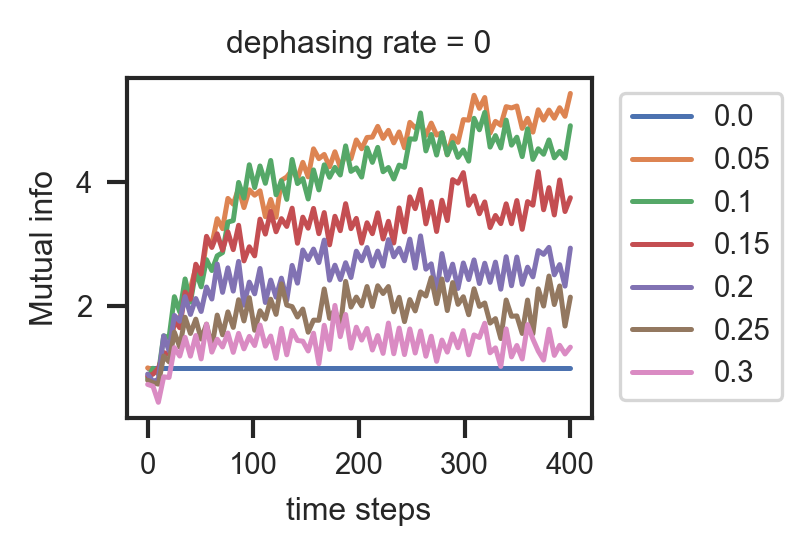

In [52]:
duration = np.linspace(0,t_total,int(t_total/dt))

t_total = 400
dt=5
steps = int(t_total/dt)

plt.figure()
rate = 0
for prob in probList: 

    N=10
    if os.path.isfile("RC_mixed_initial_state/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_mixed_initial_state/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )  
        print(np.shape(temp))
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dephasing rate = ' + str(rate))
plt.legend(probList,bbox_to_anchor= (1.03, 1) )



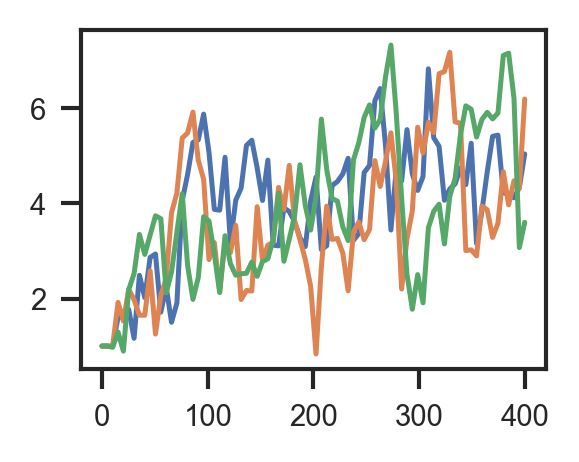

In [62]:
prob=0.1

temp = np.array(np.loadtxt("RC_mixed_initial_state/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )  
       
for i in range(3):
    plt.plot(duration, temp[i,:],'-')

    

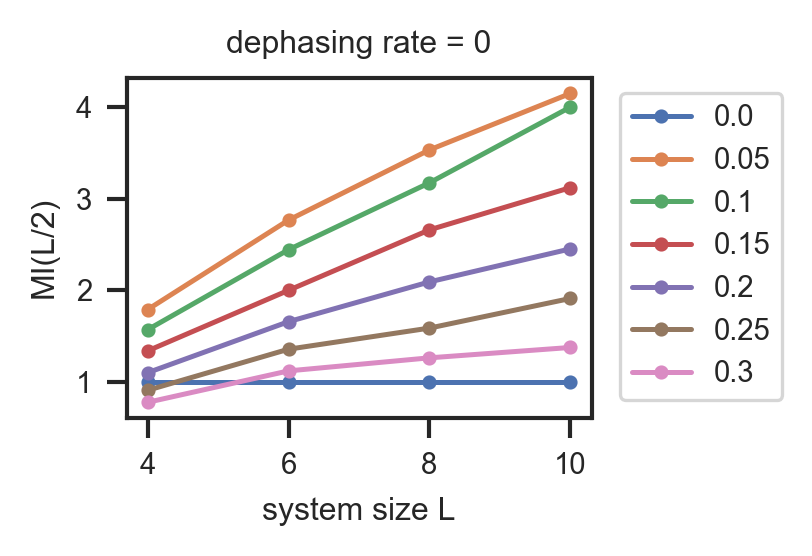

In [21]:
plt.figure()
for prob in probList:
    plt.plot(np.array(NList), avgedMI_steady_0[rate][prob],'.-')
    plt.xlabel('system size L')
    plt.ylabel('MI(L/2)')
    plt.title('dephasing rate = ' + str(rate))
plt.legend(probList,bbox_to_anchor= (1.03, 1))


In [26]:
avgedS_dynamics_0 = {}
avgedS_steady_0 = {}

for rate in rateList:
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_mixed_initial_state/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_mixed_initial_state/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedS_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedS_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedS_steady_0[rate][prob][n] = np.average(temp[steps:])



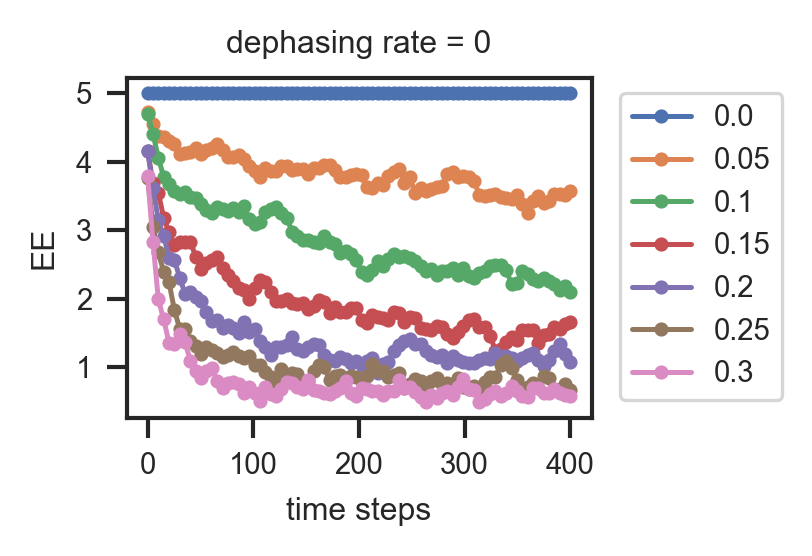

In [49]:
plt.figure()
rate = 0
for prob in probList: 

    N=8
    if os.path.isfile("RC_mixed_initial_state/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_mixed_initial_state/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('EE')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )



In [42]:
plt.figure()
for prob in probList:
    plt.plot(np.array(NList), avgedS_steady_0[rate][prob],'.-')
    plt.xlabel('system size L')
    plt.ylabel('EE(L/2)')
    
plt.legend(probList,bbox_to_anchor= (1.03, 1))


KeyError: 0

<Figure size 600x450 with 0 Axes>

In [32]:
avgedP_steady_0={}
avgedP_steady_0[rate]={}

avgedP_dynamics_0={}
avgedP_dynamics_0[rate]={}

for prob in probList: 
    avgedP_steady_0[rate][prob] = np.zeros(4)

    for (n,N) in enumerate(NList): 

        if os.path.isfile("RC_mixed_initial_state/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
            temp = np.array(np.loadtxt("RC_mixed_initial_state/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
            #print(np.average(temp,axis=0).shape)
            avgedP_dynamics_0[rate][prob] = np.average(temp,axis=0)

            steps = len(temp)//2

            avgedP_steady_0[rate][prob][n] = np.average(temp[steps:])

        #"S1_S_minus_p=0.75_r=0.01_N=10.out"
        else:
            print('missing rate=',rate,',prob=', prob,'N=',N)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



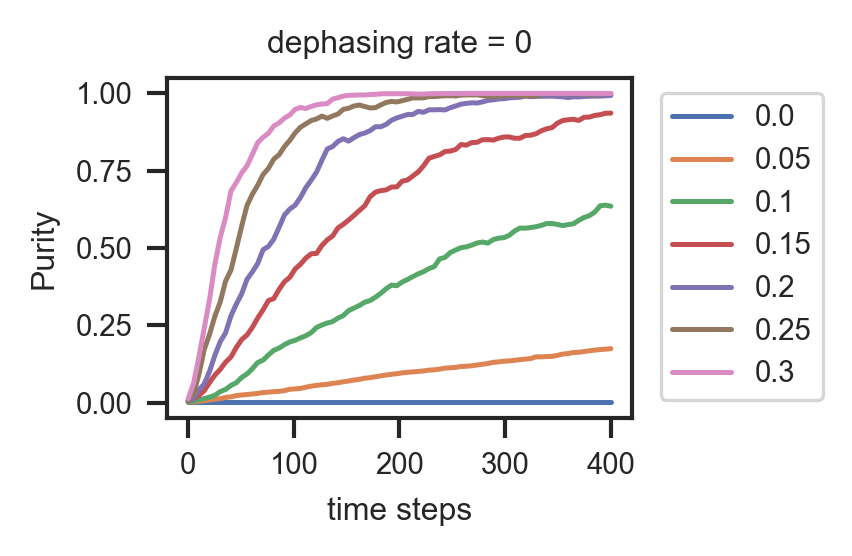

In [39]:

plt.figure()
rate =0

for prob in probList: 

    N=10
    if os.path.isfile("RC_mixed_initial_state/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_mixed_initial_state/purity_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Purity')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )

